In [57]:
# Step-I importing all the libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.cluster import KMeans, AgglomerativeClustering
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score, davies_bouldin_score
from scipy.cluster.hierarchy import dendrogram, linkage
from yellowbrick.cluster import KElbowVisualizer
import warnings
warnings.filterwarnings('ignore')

In [58]:
# Step-II Loading the dataset and dataset short descriptive statistics
Retail_df=pd.read_csv("Retail_Customer_Dataset.csv")
Retail_df.info()
Retail_df.describe()
Retail_df.head()
Retail_df.tail()
Retail_df.isnull().sum()

<class 'pandas.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 14 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   CustomerID                10000 non-null  str    
 1   Age                       10000 non-null  int64  
 2   Gender                    10000 non-null  str    
 3   Location                  10000 non-null  str    
 4   Annual_Income             10000 non-null  int64  
 5   Purchase_Frequency        10000 non-null  int64  
 6   Avg_Order_Value           10000 non-null  float64
 7   Total_Annual_Spend        10000 non-null  float64
 8   Top_Category              10000 non-null  str    
 9   Preferred_Channel         10000 non-null  str    
 10  Days_Since_Last_Purchase  10000 non-null  int64  
 11  Returns_Count             10000 non-null  int64  
 12  Satisfaction_Score        10000 non-null  float64
 13  Loyalty_Score             10000 non-null  float64
dtypes: float64(4), int

CustomerID                  0
Age                         0
Gender                      0
Location                    0
Annual_Income               0
Purchase_Frequency          0
Avg_Order_Value             0
Total_Annual_Spend          0
Top_Category                0
Preferred_Channel           0
Days_Since_Last_Purchase    0
Returns_Count               0
Satisfaction_Score          0
Loyalty_Score               0
dtype: int64

In [59]:
# Step-III Encoding categorical variables
Retail_data=Retail_df.copy()
#Check the unique values in gender
Retail_data['Gender'].unique()
#Using replace function for encoding
Retail_data['Gender_numeric'] = Retail_data['Gender'].replace({'Female': 0, 'Male': 1, 'Non-binary': 2})
Retail_data

,CustomerID,Age,Gender,Location,Annual_Income,Purchase_Frequency,Avg_Order_Value,Total_Annual_Spend,Top_Category,Preferred_Channel,Days_Since_Last_Purchase,Returns_Count,Satisfaction_Score,Loyalty_Score,Gender_numeric
0,CUST00001,43,Female,New York,45431,14,56.60,792.40,Sports,Online,1,3,3.5,5.2,0
1,CUST00002,31,Male,Los Angeles,36722,8,10.71,85.68,Automotive,Online,15,1,4.2,3.8,1
2,CUST00003,27,Male,New York,22544,11,69.91,769.01,Clothing,Online,29,0,3.3,4.5,1
3,CUST00004,24,Female,New York,60272,10,43.76,437.60,Automotive,Online,4,1,4.7,4.3,0
4,CUST00005,35,Female,Dallas,60726,14,466.30,6528.20,Books,Online,5,6,3.7,7.6,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9995,CUST09996,24,Male,Chicago,67722,13,104.34,1356.42,Sports,Online,57,1,3.3,4.9,1
9996,CUST09997,49,Non-binary,Los Angeles,82077,11,43.30,476.30,Books,Mobile App,47,2,2.9,4.3,2
9997,CUST09998,52,Male,Philadelphia,20305,10,56.01,560.10,Home & Garden,In-Store,37,2,3.7,4.2,1
9998,CUST09999,46,Female,Dallas,84171,12,18.34,220.08,Books,Mobile App,20,4,4.1,4.5,0


In [60]:
#Check the unique values in Preferred channel
Retail_data['Preferred_Channel'].unique()
#Using replace function for encoding
Retail_data['Preferred_Channel_numeric'] = Retail_data['Preferred_Channel'].replace({'Online': 0, 'In-Store': 1, 'Mobile App': 2})
Retail_data

,CustomerID,Age,Gender,Location,Annual_Income,Purchase_Frequency,Avg_Order_Value,Total_Annual_Spend,Top_Category,Preferred_Channel,Days_Since_Last_Purchase,Returns_Count,Satisfaction_Score,Loyalty_Score,Gender_numeric,Preferred_Channel_numeric
0,CUST00001,43,Female,New York,45431,14,56.60,792.40,Sports,Online,1,3,3.5,5.2,0,0
1,CUST00002,31,Male,Los Angeles,36722,8,10.71,85.68,Automotive,Online,15,1,4.2,3.8,1,0
2,CUST00003,27,Male,New York,22544,11,69.91,769.01,Clothing,Online,29,0,3.3,4.5,1,0
3,CUST00004,24,Female,New York,60272,10,43.76,437.60,Automotive,Online,4,1,4.7,4.3,0,0
4,CUST00005,35,Female,Dallas,60726,14,466.30,6528.20,Books,Online,5,6,3.7,7.6,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9995,CUST09996,24,Male,Chicago,67722,13,104.34,1356.42,Sports,Online,57,1,3.3,4.9,1,0
9996,CUST09997,49,Non-binary,Los Angeles,82077,11,43.30,476.30,Books,Mobile App,47,2,2.9,4.3,2,2
9997,CUST09998,52,Male,Philadelphia,20305,10,56.01,560.10,Home & Garden,In-Store,37,2,3.7,4.2,1,1
9998,CUST09999,46,Female,Dallas,84171,12,18.34,220.08,Books,Mobile App,20,4,4.1,4.5,0,2


In [61]:
# Step IV Selecting Features
features = ['Age', 'Annual_Income', 'Purchase_Frequency','Avg_Order_Value', 'Total_Annual_Spend','Days_Since_Last_Purchase', 
'Returns_Count','Satisfaction_Score', 'Loyalty_Score','Gender_numeric', 'Preferred_Channel_numeric']

Retail_data = Retail_data[features]
print("Final features for clustering:", Retail_data.shape)
Retail_data

Final features for clustering: (10000, 11)


,Age,Annual_Income,Purchase_Frequency,Avg_Order_Value,Total_Annual_Spend,Days_Since_Last_Purchase,Returns_Count,Satisfaction_Score,Loyalty_Score,Gender_numeric,Preferred_Channel_numeric
0,43,45431,14,56.60,792.40,1,3,3.5,5.2,0,0
1,31,36722,8,10.71,85.68,15,1,4.2,3.8,1,0
2,27,22544,11,69.91,769.01,29,0,3.3,4.5,1,0
3,24,60272,10,43.76,437.60,4,1,4.7,4.3,0,0
4,35,60726,14,466.30,6528.20,5,6,3.7,7.6,0,0
...,...,...,...,...,...,...,...,...,...,...,...
9995,24,67722,13,104.34,1356.42,57,1,3.3,4.9,1,0
9996,49,82077,11,43.30,476.30,47,2,2.9,4.3,2,2
9997,52,20305,10,56.01,560.10,37,2,3.7,4.2,1,1
9998,46,84171,12,18.34,220.08,20,4,4.1,4.5,0,2


In [62]:
# Step V Feature Scaling
scaler = StandardScaler()
Retail_scaled = scaler.fit_transform(Retail_data)

print("Scaled data shape:", Retail_scaled.shape)
Retail_scaled

Scaled data shape: (10000, 11)


array([[ 4.56983499e-01, -3.76576601e-01,  5.79736991e-01, ...,
         4.97370713e-01, -9.65925874e-01, -8.90923325e-01],
       [-5.88386509e-01, -6.35889759e-01, -1.15756295e+00, ...,
        -1.04952358e+00,  8.39543050e-01, -8.90923325e-01],
       [-9.36843178e-01, -1.05804408e+00, -2.88912980e-01, ...,
        -2.76076435e-01,  8.39543050e-01, -8.90923325e-01],
       ...,
       [ 1.24101101e+00, -1.12471099e+00, -5.78462971e-01, ...,
        -6.07553784e-01,  8.39543050e-01,  3.95980221e-01],
       [ 7.18326001e-01,  7.76918832e-01,  6.37009979e-04, ...,
        -2.76076435e-01, -9.65925874e-01,  1.68288377e+00],
       [ 6.31211834e-01, -1.34443796e-01,  6.37009979e-04, ...,
         9.39340513e-01,  8.39543050e-01,  3.95980221e-01]],
      shape=(10000, 11))

k=1 → Inertia: 110000.00
k=2 → Inertia: 93865.15
k=3 → Inertia: 84868.42
k=4 → Inertia: 79376.34
k=5 → Inertia: 74467.18
k=6 → Inertia: 71055.55
k=7 → Inertia: 67626.77
k=8 → Inertia: 64906.78
k=9 → Inertia: 62771.67
k=10 → Inertia: 61021.49


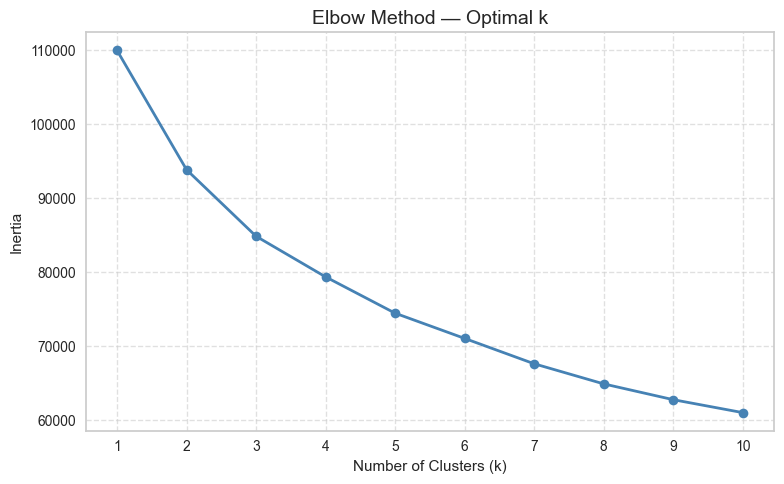

In [63]:
# Elbow method
inertia = []
k_range = range(1, 11)

for k in k_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(Retail_scaled)
    inertia.append(kmeans.inertia_)
    print(f"k={k} → Inertia: {kmeans.inertia_:.2f}")

plt.figure(figsize=(8, 5))
plt.plot(k_range, inertia, marker='o', linewidth=2, color='steelblue')
plt.title('Elbow Method — Optimal k', fontsize=14)
plt.xlabel('Number of Clusters (k)')
plt.ylabel('Inertia')
plt.xticks(k_range)
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

In [64]:
# Apply K-Means with k=4
kmeans = KMeans(n_clusters=4, random_state=42, n_init=10)
kmeans.fit(Retail_scaled)

,"n_clusters n_clusters: int, default=8The number of clusters to form as well as the number ofcentroids to generate.For an example of how to choose an optimal value for `n_clusters` refer to:ref:`sphx_glr_auto_examples_cluster_plot_kmeans_silhouette_analysis.py`.",4
,"init init: {'k-means++', 'random'}, callable or array-like of shape (n_clusters, n_features), default='k-means++'Method for initialization:* 'k-means++' : selects initial cluster centroids using sampling based on an empirical probability distribution of the points' contribution to the overall inertia. This technique speeds up convergence. The algorithm implemented is ""greedy k-means++"". It differs from the vanilla k-means++ by making several trials at each sampling step and choosing the best centroid among them.* 'random': choose `n_clusters` observations (rows) at random from data for the initial centroids.* If an array is passed, it should be of shape (n_clusters, n_features) and gives the initial centers.* If a callable is passed, it should take arguments X, n_clusters and a random state and return an initialization.For an example of how to use the different `init` strategies, see:ref:`sphx_glr_auto_examples_cluster_plot_kmeans_digits.py`.For an evaluation of the impact of initialization, see the example:ref:`sphx_glr_auto_examples_cluster_plot_kmeans_stability_low_dim_dense.py`.",'k-means++'
,"n_init n_init: 'auto' or int, default='auto'Number of times the k-means algorithm is run with different centroidseeds. The final results is the best output of `n_init` consecutive runsin terms of inertia. Several runs are recommended for sparsehigh-dimensional problems (see :ref:`kmeans_sparse_high_dim`).When `n_init='auto'`, the number of runs depends on the value of init:10 if using `init='random'` or `init` is a callable;1 if using `init='k-means++'` or `init` is an array-like... versionadded:: 1.2 Added 'auto' option for `n_init`... versionchanged:: 1.4 Default value for `n_init` changed to `'auto'`.",10
,"max_iter max_iter: int, default=300Maximum number of iterations of the k-means algorithm for asingle run.",300
,"tol tol: float, default=1e-4Relative tolerance with regards to Frobenius norm of the differencein the cluster centers of two consecutive iterations to declareconvergence.",0.0001
,"verbose verbose: int, default=0Verbosity mode.",0
,"random_state random_state: int, RandomState instance or None, default=NoneDetermines random number generation for centroid initialization. Usean int to make the randomness deterministic.See :term:`Glossary `.",42
,"copy_x copy_x: bool, default=TrueWhen pre-computing distances it is more numerically accurate to centerthe data first. If copy_x is True (default), then the original data isnot modified. If False, the original data is modified, and put backbefore the function returns, but small numerical differences may beintroduced by subtracting and then adding the data mean. Note that ifthe original data is not C-contiguous, a copy will be made even ifcopy_x is False. If the original data is sparse, but not in CSR format,a copy will be made even if copy_x is False.",True
,"algorithm algorithm: {""lloyd"", ""elkan""}, default=""lloyd""K-means algorithm to use. The classical EM-style algorithm is `""lloyd""`.The `""elkan""` variation can be more efficient on some datasets withwell-defined clusters, by using the triangle inequality. However it'smore memory intensive due to the allocation of an extra array of shape`(n_samples, n_clusters)`... versionchanged:: 0.18 Added Elkan algorithm.. versionchanged:: 1.1 Renamed ""full"" to ""lloyd"", and deprecated ""auto"" and ""full"". Changed ""auto"" to use ""lloyd"" instead of ""elkan"".",'lloyd'


In [65]:
# Assign cluster labels back to the original dataframe
Retail_data['Cluster'] = kmeans.labels_

# Check how many customers fall in each cluster
print("Cluster Distribution:")
print(Retail_data['Cluster'].value_counts().sort_index())

Cluster Distribution:
Cluster
0     845
1    4500
2    3328
3    1327
Name: count, dtype: int64


In [66]:
# Mean of each feature per cluster
cluster_profile = Retail_data.groupby('Cluster')[[ 
    'Age', 'Annual_Income', 'Purchase_Frequency',
    'Avg_Order_Value', 'Total_Annual_Spend',
    'Days_Since_Last_Purchase', 'Returns_Count',
    'Satisfaction_Score', 'Loyalty_Score'
]].mean().round(2)

print(cluster_profile)

           Age  Annual_Income  Purchase_Frequency  Avg_Order_Value  \
Cluster                                                              
0        37.93       57530.27               13.85           244.18   
1        38.08       59440.16               10.53            71.37   
2        37.31       56967.90               14.89            69.16   
3        37.63       56593.69                8.53            74.31   

         Total_Annual_Spend  Days_Since_Last_Purchase  Returns_Count  \
Cluster                                                                
0                   3272.17                     25.19           1.55   
1                    733.07                     23.13           0.82   
2                   1011.73                     21.19           2.37   
3                    620.76                     99.57           1.05   

         Satisfaction_Score  Loyalty_Score  
Cluster                                     
0                      3.81           6.08  
1          

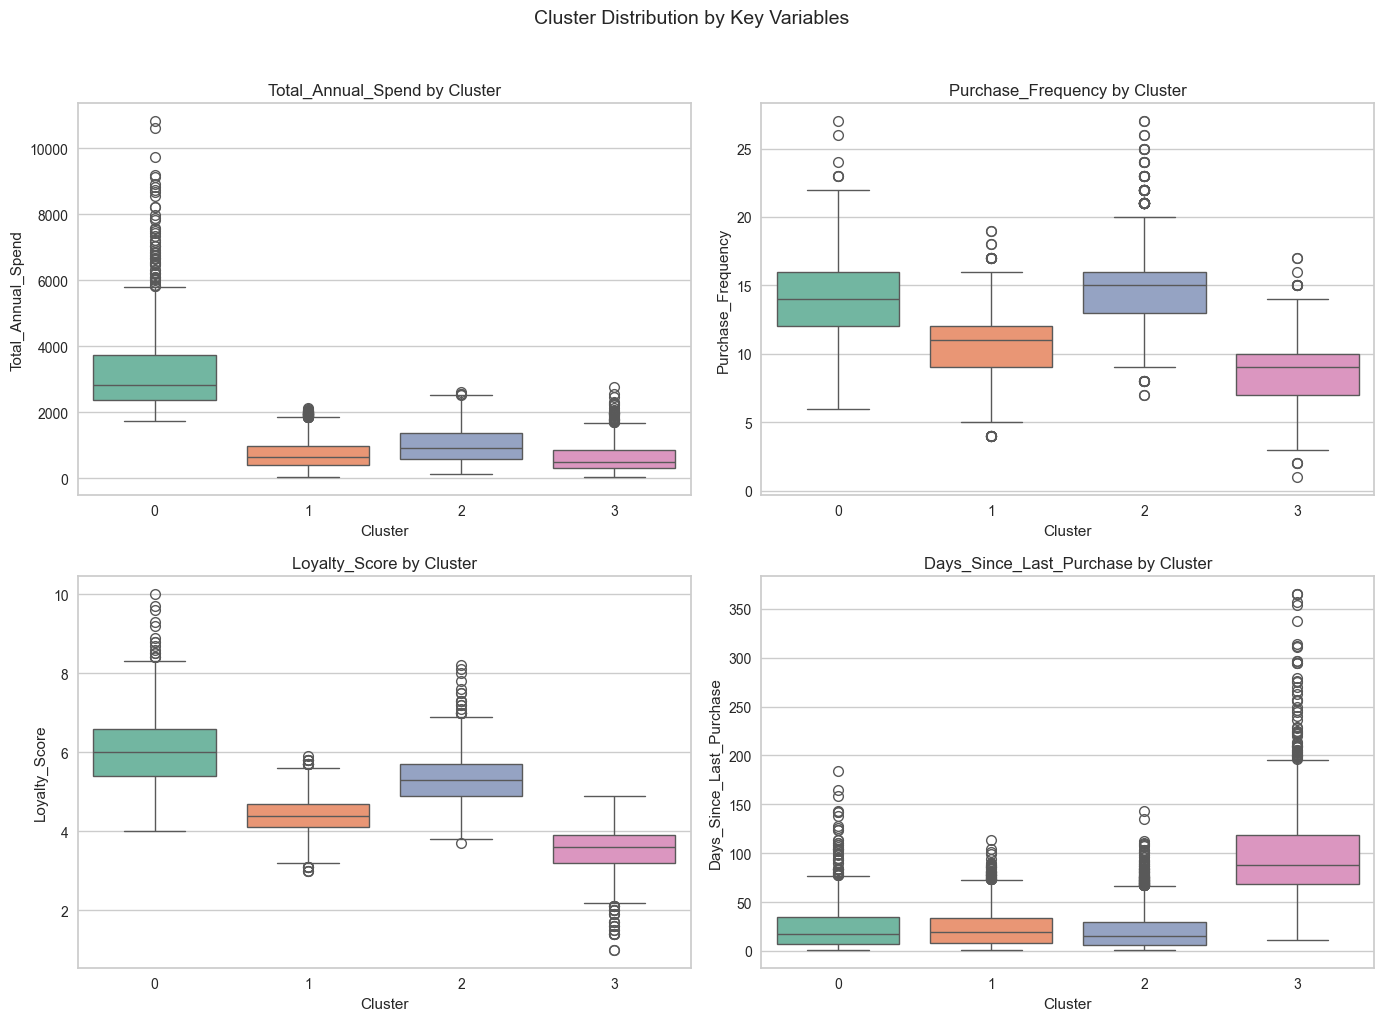

In [67]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

variables = ['Total_Annual_Spend', 'Purchase_Frequency', 
             'Loyalty_Score', 'Days_Since_Last_Purchase']

for ax, var in zip(axes.flatten(), variables):
    sns.boxplot(x='Cluster', y=var, data=Retail_data, palette='Set2', ax=ax)
    ax.set_title(f'{var} by Cluster', fontsize=12)
    ax.set_xlabel('Cluster')

plt.suptitle('Cluster Distribution by Key Variables', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

In [68]:
cluster_names = {0: 'High Value Spenders', 1: 'Satisfied Budget Shoppers', 2: 'Frequent But Cautious Shoppers',
3: 'At-Risk Inactive Customers'}

In [69]:
Retail_df['Segment']=Retail_data['Cluster'].map(cluster_names)
Retail_df

,CustomerID,Age,Gender,Location,Annual_Income,Purchase_Frequency,Avg_Order_Value,Total_Annual_Spend,Top_Category,Preferred_Channel,Days_Since_Last_Purchase,Returns_Count,Satisfaction_Score,Loyalty_Score,Segment
0,CUST00001,43,Female,New York,45431,14,56.60,792.40,Sports,Online,1,3,3.5,5.2,Frequent But Cautious Shoppers
1,CUST00002,31,Male,Los Angeles,36722,8,10.71,85.68,Automotive,Online,15,1,4.2,3.8,Satisfied Budget Shoppers
2,CUST00003,27,Male,New York,22544,11,69.91,769.01,Clothing,Online,29,0,3.3,4.5,Satisfied Budget Shoppers
3,CUST00004,24,Female,New York,60272,10,43.76,437.60,Automotive,Online,4,1,4.7,4.3,Satisfied Budget Shoppers
4,CUST00005,35,Female,Dallas,60726,14,466.30,6528.20,Books,Online,5,6,3.7,7.6,High Value Spenders
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9995,CUST09996,24,Male,Chicago,67722,13,104.34,1356.42,Sports,Online,57,1,3.3,4.9,Frequent But Cautious Shoppers
9996,CUST09997,49,Non-binary,Los Angeles,82077,11,43.30,476.30,Books,Mobile App,47,2,2.9,4.3,Satisfied Budget Shoppers
9997,CUST09998,52,Male,Philadelphia,20305,10,56.01,560.10,Home & Garden,In-Store,37,2,3.7,4.2,Satisfied Budget Shoppers
9998,CUST09999,46,Female,Dallas,84171,12,18.34,220.08,Books,Mobile App,20,4,4.1,4.5,Frequent But Cautious Shoppers


In [70]:
print(Retail_df['Segment'].value_counts())

Segment
Satisfied Budget Shoppers         4500
Frequent But Cautious Shoppers    3328
At-Risk Inactive Customers        1327
High Value Spenders                845
Name: count, dtype: int64


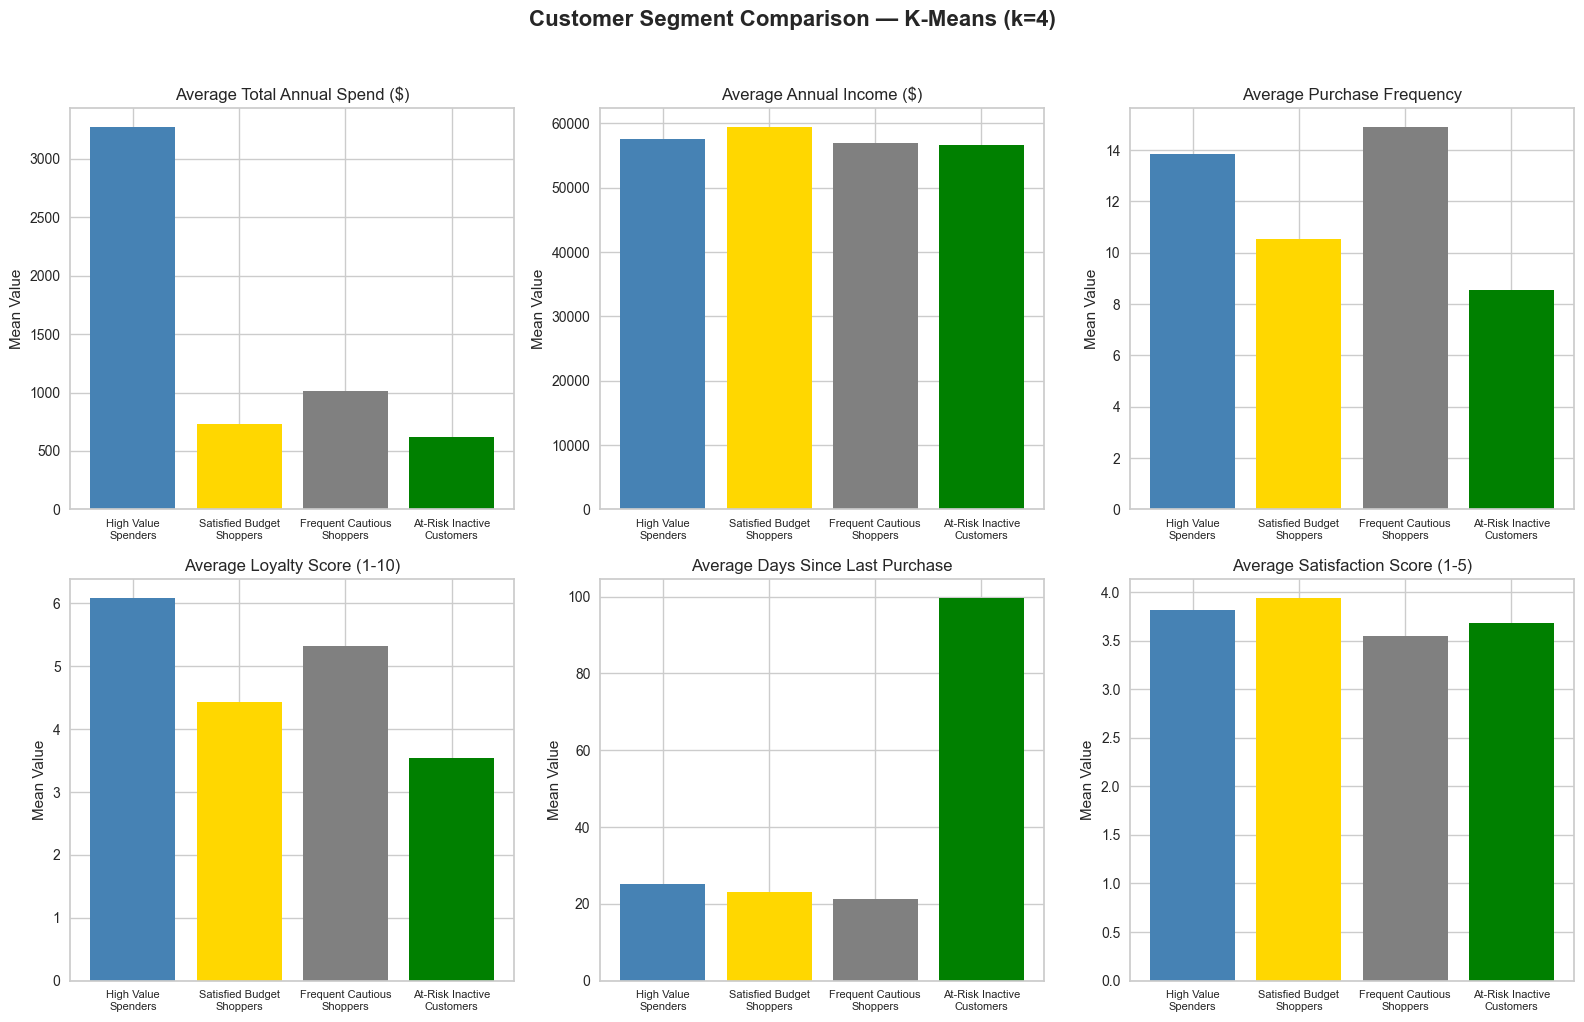

In [71]:
labels = ['High Value\nSpenders', 'Satisfied Budget\nShoppers', 'Frequent Cautious\nShoppers', 'At-Risk Inactive\nCustomers']
colors = ['steelblue', 'gold', 'gray', 'green']

metrics = [('Total_Annual_Spend', 'Average Total Annual Spend ($)'), ('Annual_Income', 'Average Annual Income ($)'),
           ('Purchase_Frequency', 'Average Purchase Frequency'), ('Loyalty_Score', 'Average Loyalty Score (1-10)'),
           ('Days_Since_Last_Purchase', 'Average Days Since Last Purchase'), ('Satisfaction_Score','Average Satisfaction Score (1-5)')]

fig, axes = plt.subplots(2, 3, figsize=(16, 10))
axes = axes.flatten()

for i, (col, title) in enumerate(metrics):
    means = Retail_data.groupby('Cluster')[col].mean()
    axes[i].bar(labels, means, color=colors)
    axes[i].set_title(title, fontsize=12)
    axes[i].set_ylabel('Mean Value')
    axes[i].tick_params(axis='x', labelsize=8)

fig.suptitle('Customer Segment Comparison — K-Means (k=4)', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

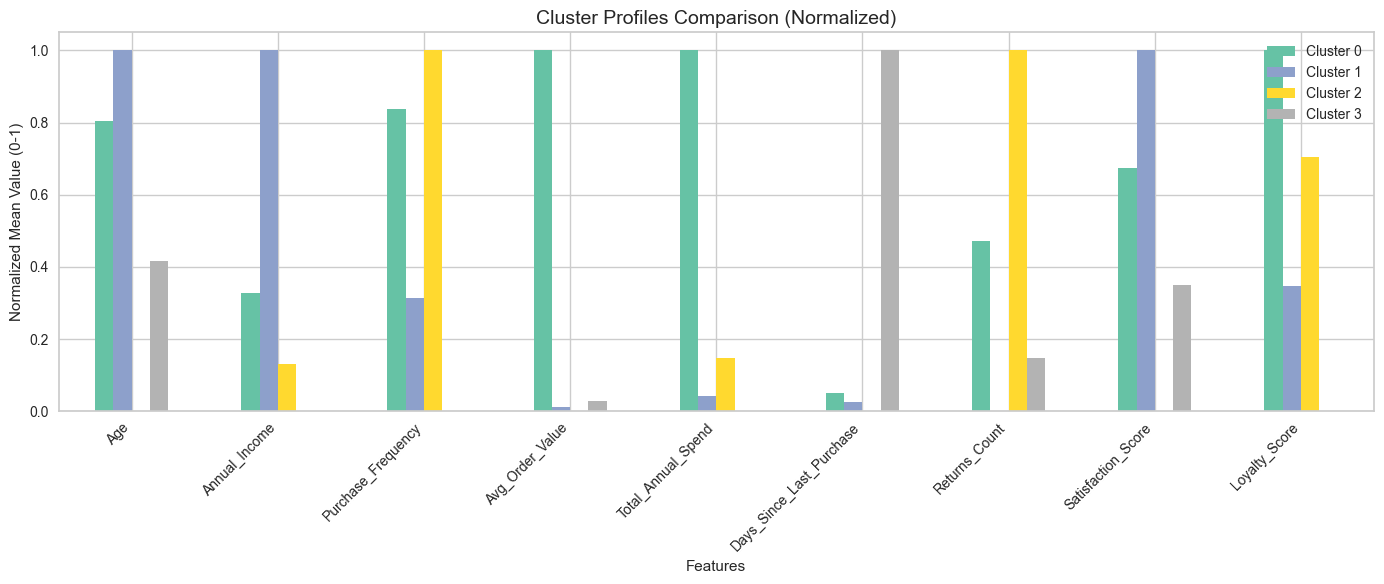

In [72]:
# Normalize cluster_profile to 0-1 scale so all variables are comparable
cluster_profile_normalized = (cluster_profile - cluster_profile.min()) / (cluster_profile.max() - cluster_profile.min())

cluster_profile_normalized.T.plot(kind='bar', figsize=(14, 6), colormap='Set2')
plt.title('Cluster Profiles Comparison (Normalized)', fontsize=14)
plt.xlabel('Features')
plt.ylabel('Normalized Mean Value (0-1)')
plt.xticks(rotation=45, ha='right')
plt.legend(['Cluster 0', 'Cluster 1', 'Cluster 2', 'Cluster 3'])
plt.tight_layout()
plt.show()